In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm
from helpers_nw import compute_N
from helpers_nw import *
import os

In [2]:
# Set the constants
T0 = 1.0                      # initial temperature
Tbar = 1.0                    # background temperature
Tw = 1.0                      # wall temperature
m = 1.0                       # mass
k = 1.0                       # Boltzmann constant

# Knudsen and Mach numbers
Kn = 0.1
Ma = 0.316

# Derived parameters
Uw = Ma * np.sqrt(k * Tw / m)          # = 0.316 wall velocity
tau = 2 * Kn / np.sqrt(np.pi / 2)     # ≈ 0.225 relaxation time

# Domain
L = 1.0
Nc = 50
dx = L / Nc                            # = 0.02

# Particles
Np = 250000                            # 5000 per cell

# Timestep from paper equation (100)
dt = 0.5 * L / (Nc * np.sqrt(k * Tw / m))  # = 0.01

# Simulation time
t_end = 50.0                            # 100 tau relaxation times
t = 0
Nsteps = int(t_end // dt) + 1

# NW bandwidth
h = 4 * dx                             # = 0.04

# Grid
x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

correlated_process = True

In [3]:
def compute_weights_NW(X, x_grid, h):
    diff = (X[None, :] - x_grid[:, None]) / h  # Nc x Np
    W = np.exp(-0.5 * diff**2)
    W /= W.sum(axis=1, keepdims=True)
    return W  # Nc x Np


def compute_cell_moments_NW(M, W, m, k, Tbar, Mbar=None, Ubar=None):
    Nc = W.shape[0]
    if Mbar is not None:
        W_col_sum = W.sum(axis=0)  # Np
        Ubar_at_X = (W.T @ Ubar) / W_col_sum[:, None]  # Np x 3
        M_corrected = M - Mbar + Ubar_at_X
    else:
        M_corrected = M
    
    U = W @ M_corrected             # Nc x 3
    
    T = np.zeros(Nc)
    for c in range(Nc):
        residuals = M_corrected - U[c]
        T[c] = (m / (3*k)) * (W[c] * (residuals**2).sum(axis=1)).sum()
        if Mbar is not None and Tbar is not None:
            T[c] += Tbar
    
    return U, T
'''
def compute_cell_moments_NW(M, W, m, k, Tbar, Mbar=None, Ubar=None):
    Nc = W.shape[0]
    
    if Mbar is not None:
        W_col_sum = W.sum(axis=0)
        Ubar_at_X = (W.T @ Ubar) / W_col_sum[:, None]
        M_corrected = M - Mbar + Ubar_at_X
    else:
        M_corrected = M
    
    # U from variance-reduced estimator
    U = W @ M_corrected 
    
    # T from raw M — NOT M_corrected
    T = np.zeros(Nc)
    for c in range(Nc):
        U_raw = W[c] @ M          # raw mean
        residuals = M - U_raw     # raw fluctuations
        T[c] = (m/(3*k)) * (W[c] * (residuals**2).sum(axis=1)).sum()
    
    return U, T
'''

'\ndef compute_cell_moments_NW(M, W, m, k, Tbar, Mbar=None, Ubar=None):\n    Nc = W.shape[0]\n\n    if Mbar is not None:\n        W_col_sum = W.sum(axis=0)\n        Ubar_at_X = (W.T @ Ubar) / W_col_sum[:, None]\n        M_corrected = M - Mbar + Ubar_at_X\n    else:\n        M_corrected = M\n\n    # U from variance-reduced estimator\n    U = W @ M_corrected \n\n    # T from raw M — NOT M_corrected\n    T = np.zeros(Nc)\n    for c in range(Nc):\n        U_raw = W[c] @ M          # raw mean\n        residuals = M - U_raw     # raw fluctuations\n        T[c] = (m/(3*k)) * (W[c] * (residuals**2).sum(axis=1)).sum()\n\n    return U, T\n'

In [4]:
def evolve_velocity_M(M, mask, U_particle, T_particle, dt, tau, m, k, noise):
    M[mask] = (M[mask] - U_particle) * np.exp(-dt/tau) \
            + U_particle \
            + np.sqrt((k * T_particle / m) * (1 - np.exp(-2*dt/tau)))[:, None] * noise

def evolve_velocity_Mbar(Mbar, N, mask, dt, tau, m, k, Tbar, noise, NiNi):
    Mbar[mask] = np.exp(-dt/tau) * Mbar[mask] \
               + dt * N[mask] \
               + np.sqrt(np.maximum((k*Tbar/m) * (1 - np.exp(-2*dt/tau)) - dt**2 * NiNi[mask], 0.0)) * noise
    Mbar[mask] = np.clip(Mbar[mask], -10*np.sqrt(k*Tbar/m), 10*np.sqrt(k*Tbar/m))


In [5]:
def apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar):
    theta_w = np.sqrt(k * Tw / m)
    theta_bar = np.sqrt(k * Tbar / m)
    
    # Left wall
    left_mask = X < -L/2
    if left_mask.any():
        X[left_mask] = -L/2
        N_left = left_mask.sum()
        r1_left = np.random.uniform(size=N_left)
        r2_left = np.random.uniform(size=N_left)
        r3_left = np.random.uniform(size=N_left)
        
        # Half-Maxwellian for wall-normal (must go right → positive)
        M[left_mask, 0] = theta_w * np.sqrt(-2 * np.log(r1_left))  
        M[left_mask, 1] = theta_w * np.sqrt(-2 * np.log(r2_left)) * np.sin(2*np.pi*r3_left) + Uw
        M[left_mask, 2] = theta_w * np.sqrt(-2 * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
        
        Mbar[left_mask, 0] = theta_bar * np.sqrt(-2 * np.log(r1_left))
        Mbar[left_mask, 1] = theta_bar * np.sqrt(-2 * np.log(r2_left)) * np.sin(2*np.pi*r3_left)
        Mbar[left_mask, 2] = theta_bar * np.sqrt(-2 * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
    
    # Right wall
    right_mask = X > L/2
    if right_mask.any():
        X[right_mask] = L/2
        N_right = right_mask.sum()
        r1_right = np.random.uniform(size=N_right)
        r2_right = np.random.uniform(size=N_right)
        r3_right = np.random.uniform(size=N_right)
        
        # Half-Maxwellian for wall-normal (must go left → negative)
        M[right_mask, 0] = -theta_w * np.sqrt(-2 * np.log(r1_right))  # ✅
        M[right_mask, 1] = theta_w * np.sqrt(-2 * np.log(r2_right)) * np.sin(2*np.pi*r3_right) - Uw
        M[right_mask, 2] = theta_w * np.sqrt(-2 * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
        
        Mbar[right_mask, 0] = -theta_bar * np.sqrt(-2 * np.log(r1_right))  # ✅
        Mbar[right_mask, 1] = theta_bar * np.sqrt(-2 * np.log(r2_right)) * np.sin(2*np.pi*r3_right)
        Mbar[right_mask, 2] = theta_bar * np.sqrt(-2 * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
    
    return left_mask, right_mask

In [6]:
# Implementation of Algorithm 1 
X = np.random.uniform(low=-L/2, high=L/2, size=Np) 

r1 = np.random.uniform(size=Np) 
r2 = np.random.uniform(size=Np) 
r3 = np.random.uniform(size=Np) 
r4 = np.random.uniform(size=Np) 

M = np.zeros((Np, 3)) 
M[:, 0] = np.sqrt(-2 * k * T0 / m * np.log(r1)) * np.cos(2 * np.pi * r2) 
M[:, 1] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.sin(2 * np.pi * r4) 
M[:, 2] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.cos(2 * np.pi * r4) 

# Mbar: use same r's for correlation
Mbar = np.zeros((Np, 3)) 

Mbar[:, 0] = np.sqrt(-2 * k * Tbar / m * np.log(r1)) * np.cos(2*np.pi*r2)
Mbar[:, 1] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.sin(2*np.pi*r4)
Mbar[:, 2] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.cos(2*np.pi*r4)

U = np.zeros((Nsteps, Nc, 3)) 
T = np.zeros([Nsteps, Nc]) 

x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

Ubar = np.zeros((Nc, 3))

W = compute_weights_NW(X, x_grid, h)

if correlated_process:
    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
else:
    U[0], T[0] = compute_cell_moments_NW(M, W, m, k, Tbar)


for step in tqdm(range(1, Nsteps)):

    # Evolve X^i 
    X = X + dt * M[:, 0] 
    
    # Apply B.C. 
    left_mask, right_mask = apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar) 
    mask_wall = left_mask | right_mask # particles that just hit wall 
    
    # Compute weights once per step
    W = compute_weights_NW(X, x_grid, h)
    
    # Sort particles 
    if correlated_process:    
        N, NiNi = compute_N(M, Mbar, U[step-1], W, dx, m, k, Tbar, tau)

    # For debugging
        if step in [1, 10, 50, 100, 200, 500, 750]:
            alpha = compute_alpha(M, Mbar, W, dx)
            cbar = compute_cbar(M, Mbar, U[step-1], W, dx, m, k, Tbar, tau)
            
            print(f"\n{'='*50}")
            print(f"Step {step}")
            print(f"{'='*50}")
            
            print(f"\n  N statistics:")
            for d, name in enumerate(['x','y','z']):
                print(f"    N[{name}]: mean={np.mean(N[:,d]):+.4f}  std={np.std(N[:,d]):.4f}  max={np.abs(N[:,d]).max():.4f}")
            
            print(f"\n  Particle statistics:")
            print(f"    std(Mbar[:,0]) = {np.std(Mbar[:,0]):.4f}")
            print(f"    std(M-Mbar)    = {np.std(M[:,0]-Mbar[:,0]):.4f}")
            print(f"    mean(M-Mbar)   = {np.mean(M[:,0]-Mbar[:,0]):.4f}")
            
            print(f"\n  Coefficient statistics:")
            print(f"    alpha: mean={np.mean(alpha):+.4f}  std={np.std(alpha):.4f}  max={np.abs(alpha).max():.4f}")
            print(f"    cbar:  mean={np.mean(cbar):+.4f}  std={np.std(cbar):.4f}  max={np.abs(cbar).max():.4f}")
            print(f"    cbar diagonal only:")
            for d in range(3):
                print(f"      cbar[{d},{d}]: mean={np.mean(cbar[:,d,d]):+.4f}  std={np.std(cbar[:,d,d]):.4f}")
            
            # Energy correction health check
            NiNi = compute_NiNi_analytical(alpha, cbar, 
                   compute_gammabar(alpha, M, Mbar, W, dx, m, k, Tbar),
                   -((m/(2*k*Tbar))**2)/tau, tau, Tbar)
            Atilde = (k*Tbar/m)*(1-np.exp(-2*dt/tau)) - dt**2 * NiNi
            print(f"\n  Energy correction A_tilde:")
            print(f"    min={Atilde.min():.6f}  mean={Atilde.mean():.6f}")
            pct_negative = 100 * np.mean(Atilde < 0)
            print(f"    % negative (clamped to 0): {pct_negative:.1f}%")
            print(f"{'='*50}\n")
    
            print(f"U[step,:,0] (wall-normal, should be ~0):")
            print(U[step-1,:,0])
            print(f"U[step,:,1] (streamwise, should be linear):")  
            print(U[step-1,:,1])

    
    W_col_sum = W.sum(axis=0)  # Nc x Np summed over Nc -> shape (Np,)
    T_at_particle = (W.T @ T[step-1]) / W_col_sum   # Np
    U_at_particle = (W.T @ U[step-1]) / W_col_sum[:, None]  # Np x 3

    mask_update = ~mask_wall # exclude wall-hitting particles, because they are already handled  
    
    # Evolve V^i
    noise = np.random.normal(0,1,size=M[mask_update].shape) # Common noise
    evolve_velocity_M(M, mask_update, U_at_particle[mask_update], T_at_particle[mask_update], dt, tau, m, k, noise)

    if correlated_process:
        # Interpolate to particles
        W_col_sum = W.sum(axis=0)
        NiNi_at_particle = (W.T @ NiNi) / W_col_sum[:, None]  # Np x 3
        #evolve_velocity_Mbar(Mbar, N, mask_update, dt, tau, m, k, Tbar, noise) 
        evolve_velocity_Mbar(Mbar, N, mask_update, dt, tau, m, k, Tbar, noise, NiNi_at_particle)
        
        #Ubar = W @ Mbar 
        U[step], T[step] = compute_cell_moments_NW(M, W, m, k, Tbar, Mbar, Ubar)
    else:
        U[step], T[step] = compute_cell_moments_NW(M, W, m, k, Tbar)

  0%|                                                  | 0/4999 [00:00<?, ?it/s]


Step 1

  N statistics:
    N[x]: mean=-0.0000  std=0.0000  max=0.0000
    N[y]: mean=+0.0000  std=0.0000  max=0.0000
    N[z]: mean=-0.0000  std=0.0000  max=0.0000

  Particle statistics:
    std(Mbar[:,0]) = 0.9991
    std(M-Mbar)    = 0.0000
    mean(M-Mbar)   = 0.0000

  Coefficient statistics:
    alpha: mean=+0.0000  std=0.0000  max=0.0000
    cbar:  mean=-2.0889  std=2.9541  max=6.2666
    cbar diagonal only:
      cbar[0,0]: mean=-6.2666  std=0.0000
      cbar[1,1]: mean=-6.2666  std=0.0000
      cbar[2,2]: mean=-6.2666  std=0.0000

  Energy correction A_tilde:
    min=0.109205  mean=0.109205
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
U[step,:,1] (streamwise, should be linear):
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

  0%|                                          | 9/4999 [00:04<46:17,  1.80it/s]


Step 10

  N statistics:
    N[x]: mean=+0.0000  std=0.0028  max=0.0210
    N[y]: mean=-0.0000  std=0.0021  max=0.0136
    N[z]: mean=-0.0000  std=0.0021  max=0.0137

  Particle statistics:
    std(Mbar[:,0]) = 1.0035
    std(M-Mbar)    = 0.0074
    mean(M-Mbar)   = -0.0000

  Coefficient statistics:
    alpha: mean=-0.0000  std=0.0006  max=0.0017
    cbar:  mean=-2.0882  std=2.9532  max=6.2670
    cbar diagonal only:
      cbar[0,0]: mean=-6.2643  std=0.0017
      cbar[1,1]: mean=-6.2648  std=0.0013
      cbar[2,2]: mean=-6.2648  std=0.0014

  Energy correction A_tilde:
    min=0.109205  mean=0.109208
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[-8.68193209e-04 -8.29762332e-04 -7.83981918e-04 -7.30789085e-04
 -6.70632032e-04 -6.04571386e-04 -5.34288733e-04 -4.61965785e-04
 -3.90037761e-04 -3.20876835e-04 -2.56495806e-04 -1.98354407e-04
 -1.47304075e-04 -1.03650775e-04 -6.72807071e-05 -3.77931559e-05
 -1.46093985e-05  2.94328741e-06  1.55569993e-05  2

  1%|▍                                        | 49/4999 [00:25<41:59,  1.96it/s]

...

 10%|███▉                                    | 499/4999 [04:35<45:43,  1.64it/s]


Step 500

  N statistics:
    N[x]: mean=-0.0000  std=0.0010  max=0.0050
    N[y]: mean=+0.0000  std=0.0009  max=0.0057
    N[z]: mean=+0.0000  std=0.0009  max=0.0050

  Particle statistics:
    std(Mbar[:,0]) = 1.0025
    std(M-Mbar)    = 0.0006
    mean(M-Mbar)   = -0.0000

  Coefficient statistics:
    alpha: mean=+0.0000  std=0.0000  max=0.0002
    cbar:  mean=-2.0886  std=2.9537  max=6.2663
    cbar diagonal only:
      cbar[0,0]: mean=-6.2656  std=0.0002
      cbar[1,1]: mean=-6.2657  std=0.0002
      cbar[2,2]: mean=-6.2657  std=0.0002

  Energy correction A_tilde:
    min=0.109206  mean=0.109207
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[-4.32147740e-04 -4.26038516e-04 -4.18102895e-04 -4.08202233e-04
 -3.96274849e-04 -3.82361466e-04 -3.66616816e-04 -3.49299014e-04
 -3.30734905e-04 -3.11269536e-04 -2.91215501e-04 -2.70817960e-04
 -2.50243412e-04 -2.29589945e-04 -2.08909689e-04 -1.88232767e-04
 -1.67584990e-04 -1.46996095e-04 -1.26499483e-04 -

 15%|█████▉                                  | 749/4999 [06:43<34:17,  2.07it/s]


Step 750

  N statistics:
    N[x]: mean=-0.0000  std=0.0010  max=0.0051
    N[y]: mean=+0.0000  std=0.0009  max=0.0045
    N[z]: mean=-0.0000  std=0.0009  max=0.0050

  Particle statistics:
    std(Mbar[:,0]) = 1.0008
    std(M-Mbar)    = 0.0006
    mean(M-Mbar)   = -0.0000

  Coefficient statistics:
    alpha: mean=-0.0000  std=0.0000  max=0.0002
    cbar:  mean=-2.0886  std=2.9537  max=6.2663
    cbar diagonal only:
      cbar[0,0]: mean=-6.2656  std=0.0002
      cbar[1,1]: mean=-6.2657  std=0.0002
      cbar[2,2]: mean=-6.2657  std=0.0002

  Energy correction A_tilde:
    min=0.109206  mean=0.109207
    % negative (clamped to 0): 0.0%

U[step,:,0] (wall-normal, should be ~0):
[-4.37097538e-04 -4.31292363e-04 -4.23768376e-04 -4.14342566e-04
 -4.02893652e-04 -3.89395666e-04 -3.73942324e-04 -3.56750736e-04
 -3.38137576e-04 -3.18470822e-04 -2.98110721e-04 -2.77358357e-04
 -2.56426192e-04 -2.35435185e-04 -2.14433509e-04 -1.93426608e-04
 -1.72407952e-04 -1.51382564e-04 -1.30379124e-04 -

100%|███████████████████████████████████████| 4999/4999 [44:07<00:00,  1.89it/s]


In [7]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


Metric                                     Value
MSE U2 (streamwise)                     0.003540
MSE U1 (wall-normal, ~0)                0.000000
MSE T                                   0.000684
Max error U2                            0.113293
Max error T                             0.036146
Boundary bias T left                   -0.000019
Boundary bias T right                  -0.000019
Mean temporal var U2                    0.000000
T center (sim)                          1.001285
T center (analytical)                   1.037431
T wall left (sim)                       1.001464
T wall right (sim)                      1.001464


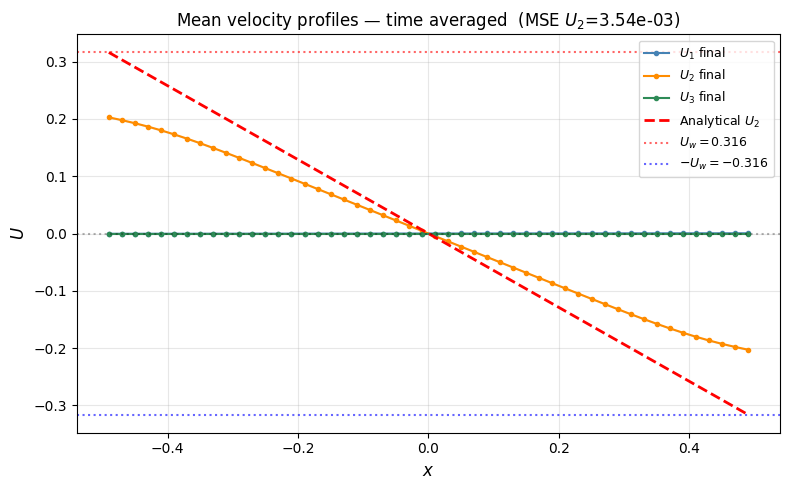

Saved: figs/presentation/velocity_profile.pdf


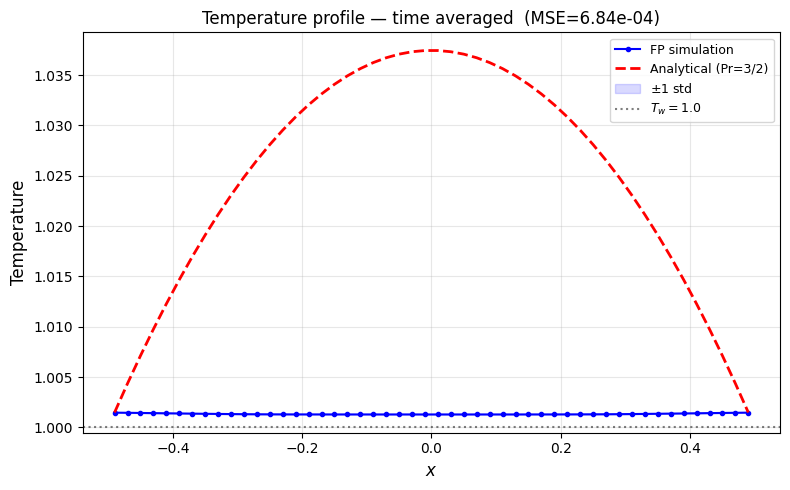

Saved: figs/presentation/temperature_profile.pdf
T center analytical: 1.037431
T wall   analytical: 1.001483
Delta T  analytical: 0.037431


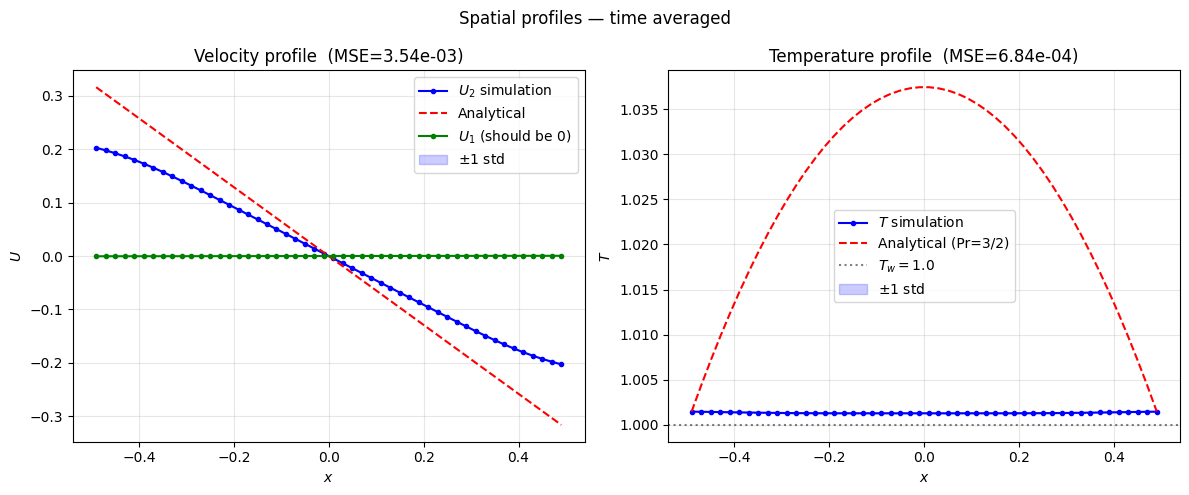

Saved: figs/profiles.pdf


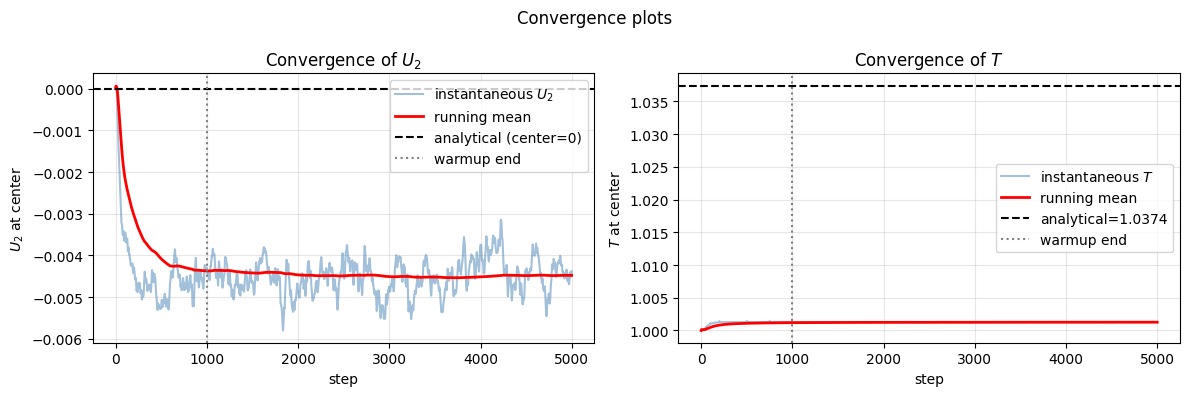

Saved: figs/convergence.pdf


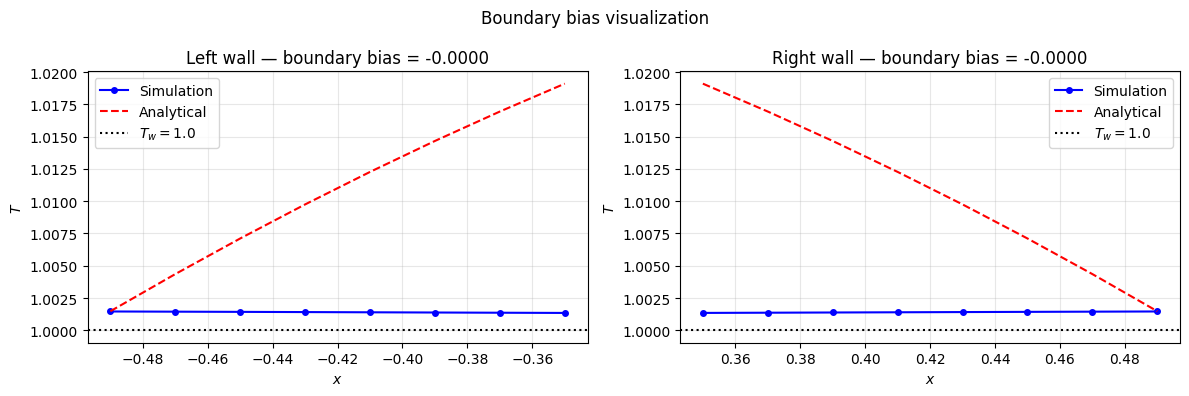

Saved: figs/boundary_bias.pdf


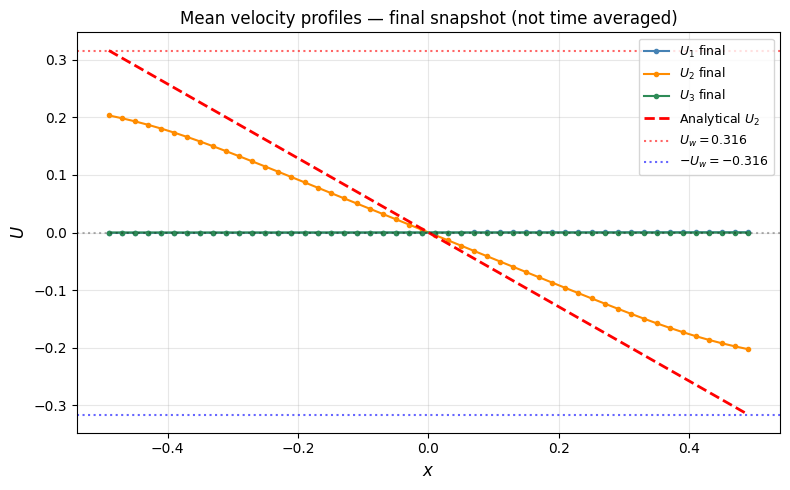

Saved: figs/velocity_final_snapshot.pdf


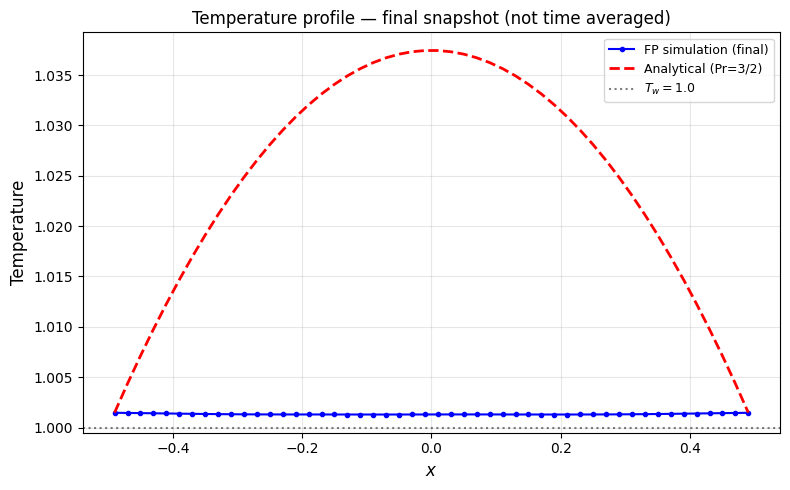

Saved: figs/temperature_final_snapshot.pdf
T center (final snapshot): 1.001300
T wall   (final snapshot): 1.001466


In [8]:
# ============================================================
# SETUP
# ============================================================
os.makedirs('figs', exist_ok=True)
os.makedirs('figs/presentation', exist_ok=True)

warmup = 1000  # ~10 tau

Pr = 3/2
U_analytical = np.linspace(Uw, -Uw, Nc)
T_analytical = Tw + (Pr/2) * (Uw**2/2) * (1 - 4*x_grid**2/L**2)

U_avg = np.mean(U[warmup:], axis=0)  # (Nc, 3)
T_avg = np.mean(T[warmup:], axis=0)  # (Nc,)
U_var = np.var(U[warmup:, :, 1], axis=0)
T_var = np.var(T[warmup:], axis=0)

MSE_U2 = np.mean((U_avg[:, 1] - U_analytical)**2)
MSE_U1 = np.mean(U_avg[:, 0]**2)
MSE_T  = np.mean((T_avg - T_analytical)**2)
MAE_U2 = np.max(np.abs(U_avg[:, 1] - U_analytical))
MAE_T  = np.max(np.abs(T_avg - T_analytical))
bias_T_left  = T_avg[0]  - T_analytical[0]
bias_T_right = T_avg[-1] - T_analytical[-1]

print(f"\n{'='*50}")
print(f"{'Metric':<35} {'Value':>12}")
print(f"{'='*50}")
print(f"{'MSE U2 (streamwise)':<35} {MSE_U2:>12.6f}")
print(f"{'MSE U1 (wall-normal, ~0)':<35} {MSE_U1:>12.6f}")
print(f"{'MSE T':<35} {MSE_T:>12.6f}")
print(f"{'Max error U2':<35} {MAE_U2:>12.6f}")
print(f"{'Max error T':<35} {MAE_T:>12.6f}")
print(f"{'Boundary bias T left':<35} {bias_T_left:>12.6f}")
print(f"{'Boundary bias T right':<35} {bias_T_right:>12.6f}")
print(f"{'Mean temporal var U2':<35} {U_var.mean():>12.6f}")
print(f"{'T center (sim)':<35} {T_avg[Nc//2]:>12.6f}")
print(f"{'T center (analytical)':<35} {T_analytical[Nc//2]:>12.6f}")
print(f"{'T wall left (sim)':<35} {T_avg[0]:>12.6f}")
print(f"{'T wall right (sim)':<35} {T_avg[-1]:>12.6f}")
print(f"{'='*50}")

# ============================================================
# figs/presentation — PLOT A: U final snapshot (all 3 components)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
for i in range(3):
    ax.plot(x_grid, U_avg[:, i], 'o-', color=colors[i],
            markersize=3, label=f'$U_{i+1}$ final')
ax.fill_between(x_grid,
    U_avg[:, 1] - np.sqrt(U_var),
    U_avg[:, 1] + np.sqrt(U_var),
    alpha=0.15, color='steelblue')
ax.plot(x_grid, U_analytical, 'r--', linewidth=2, label='Analytical $U_2$')
ax.axhline(y=Uw,  color='r', linestyle=':', alpha=0.6, label=f'$U_w={Uw:.3f}$')
ax.axhline(y=-Uw, color='b', linestyle=':', alpha=0.6, label=f'$-U_w={-Uw:.3f}$')
ax.axhline(y=0,   color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$U$', fontsize=12)
ax.set_title(f'Mean velocity profiles — time averaged  (MSE $U_2$={MSE_U2:.2e})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/presentation/velocity_profile.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/presentation/velocity_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/presentation/velocity_profile.pdf")

# ============================================================
# figs/presentation — PLOT B: T profile with analytical
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_grid, T_avg, 'b-o', markersize=3, label='FP simulation')
ax.plot(x_grid, T_analytical, 'r--', linewidth=2, label='Analytical (Pr=3/2)')
ax.fill_between(x_grid,
    T_avg - np.sqrt(T_var),
    T_avg + np.sqrt(T_var),
    alpha=0.15, color='blue', label='$\pm 1$ std')
ax.axhline(y=Tw, color='k', linestyle=':', alpha=0.5, label=f'$T_w={Tw}$')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Temperature', fontsize=12)
ax.set_title(f'Temperature profile — time averaged  (MSE={MSE_T:.2e})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/presentation/temperature_profile.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/presentation/temperature_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: figs/presentation/temperature_profile.pdf")
print(f"T center analytical: {T_analytical[Nc//2]:.6f}")
print(f"T wall   analytical: {T_analytical[0]:.6f}")
print(f"Delta T  analytical: {T_analytical[Nc//2] - Tw:.6f}")

# ============================================================
# figs/ — PLOT 1: Profiles side by side (time averaged)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x_grid, U_avg[:, 1], 'b-o', markersize=3, label='$U_2$ simulation')
axes[0].plot(x_grid, U_analytical, 'r--', label='Analytical')
axes[0].plot(x_grid, U_avg[:, 0], 'g-o', markersize=3, label='$U_1$ (should be 0)')
axes[0].fill_between(x_grid,
    U_avg[:, 1] - np.sqrt(U_var),
    U_avg[:, 1] + np.sqrt(U_var),
    alpha=0.2, color='blue', label='$\pm 1$ std')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$U$')
axes[0].set_title(f'Velocity profile  (MSE={MSE_U2:.2e})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_grid, T_avg, 'b-o', markersize=3, label='$T$ simulation')
axes[1].plot(x_grid, T_analytical, 'r--', label='Analytical (Pr=3/2)')
axes[1].axhline(y=Tw, color='k', linestyle=':', alpha=0.5, label='$T_w=1.0$')
axes[1].fill_between(x_grid,
    T_avg - np.sqrt(T_var),
    T_avg + np.sqrt(T_var),
    alpha=0.2, color='blue', label='$\pm 1$ std')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$T$')
axes[1].set_title(f'Temperature profile  (MSE={MSE_T:.2e})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Spatial profiles — time averaged')
plt.tight_layout()
plt.savefig('figs/profiles.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/profiles.pdf")

# ============================================================
# figs/ — PLOT 2: Convergence over time
# ============================================================
center = Nc // 2
running_mean_U = np.cumsum(U[:, center, 1]) / np.arange(1, Nsteps+1)
running_mean_T = np.cumsum(T[:, center])    / np.arange(1, Nsteps+1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(U[:, center, 1], alpha=0.5, color='steelblue', label='instantaneous $U_2$')
axes[0].plot(running_mean_U, 'r-', linewidth=2, label='running mean')
axes[0].axhline(y=0.0, color='k', linestyle='--', label='analytical (center=0)')
axes[0].axvline(x=warmup, color='gray', linestyle=':', label='warmup end')
axes[0].set_xlabel('step')
axes[0].set_ylabel('$U_2$ at center')
axes[0].set_title('Convergence of $U_2$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(T[:, center], alpha=0.5, color='steelblue', label='instantaneous $T$')
axes[1].plot(running_mean_T, 'r-', linewidth=2, label='running mean')
axes[1].axhline(y=T_analytical[center], color='k', linestyle='--',
                label=f'analytical={T_analytical[center]:.4f}')
axes[1].axvline(x=warmup, color='gray', linestyle=':', label='warmup end')
axes[1].set_xlabel('step')
axes[1].set_ylabel('$T$ at center')
axes[1].set_title('Convergence of $T$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Convergence plots')
plt.tight_layout()
plt.savefig('figs/convergence.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/convergence.pdf")

# ============================================================
# figs/ — PLOT 3: Boundary bias zoom
# ============================================================
n_wall = 8

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_grid[:n_wall], T_avg[:n_wall], 'b-o', markersize=4, label='Simulation')
axes[0].plot(x_grid[:n_wall], T_analytical[:n_wall], 'r--', label='Analytical')
axes[0].axhline(y=Tw, color='k', linestyle=':', label='$T_w=1.0$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$T$')
axes[0].set_title(f'Left wall — boundary bias = {bias_T_left:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_grid[-n_wall:], T_avg[-n_wall:], 'b-o', markersize=4, label='Simulation')
axes[1].plot(x_grid[-n_wall:], T_analytical[-n_wall:], 'r--', label='Analytical')
axes[1].axhline(y=Tw, color='k', linestyle=':', label='$T_w=1.0$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$T$')
axes[1].set_title(f'Right wall — boundary bias = {bias_T_right:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Boundary bias visualization')
plt.tight_layout()
plt.savefig('figs/boundary_bias.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/boundary_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/boundary_bias.pdf")

# ============================================================
# figs/ — PLOT 4: Final snapshot velocity (not time averaged)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
for i in range(3):
    ax.plot(x_grid, U[-1, :, i], 'o-', color=colors[i],
            markersize=3, label=f'$U_{i+1}$ final')
ax.plot(x_grid, U_analytical, 'r--', linewidth=2, label='Analytical $U_2$')
ax.axhline(y=Uw,  color='r', linestyle=':', alpha=0.6, label=f'$U_w={Uw:.3f}$')
ax.axhline(y=-Uw, color='b', linestyle=':', alpha=0.6, label=f'$-U_w={-Uw:.3f}$')
ax.axhline(y=0,   color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('$U$', fontsize=12)
ax.set_title('Mean velocity profiles — final snapshot (not time averaged)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/velocity_final_snapshot.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/velocity_final_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figs/velocity_final_snapshot.pdf")

# ============================================================
# figs/ — PLOT 5: Final snapshot temperature (not time averaged)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_grid, T[-1, :], 'b-o', markersize=3, label='FP simulation (final)')
ax.plot(x_grid, T_analytical, 'r--', linewidth=2, label='Analytical (Pr=3/2)')
ax.axhline(y=Tw, color='k', linestyle=':', alpha=0.5, label=f'$T_w={Tw}$')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Temperature', fontsize=12)
ax.set_title('Temperature profile — final snapshot (not time averaged)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figs/temperature_final_snapshot.pdf', dpi=150, bbox_inches='tight')
plt.savefig('figs/temperature_final_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: figs/temperature_final_snapshot.pdf")
print(f"T center (final snapshot): {T[-1, Nc//2]:.6f}")
print(f"T wall   (final snapshot): {T[-1, 0]:.6f}")